In [113]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import seaborn as sns
from io import StringIO

folder = './Data/'
file_path = os.path.join(folder, 'widthConstant.csv')

df = pd.read_csv(file_path, header=None)


# Print the shape to verify
print(f"DataFrame shape: {df.shape}")


DataFrame shape: (488, 112)


In [114]:
# Separate metadata from width measurements
metadata = df.iloc[:, :3].copy()
metadata.columns = ['y_coordinate', 'z_coordinate', 'power']
width_data = df.iloc[:, 3:-4].copy()

In [115]:
y_values = metadata['y_coordinate'].values

In [116]:
y_values.max()

np.float64(3.4)

In [117]:
width_data = width_data[metadata['y_coordinate'] != y_values.max()]
metadata = metadata[metadata['y_coordinate'] != y_values.max()]

In [118]:
# remove the data with the current max y 

In [119]:
width_data.shape

(478, 105)

In [120]:
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(width_data)

In [121]:
MAX_NUM_CLUSTERS = 12

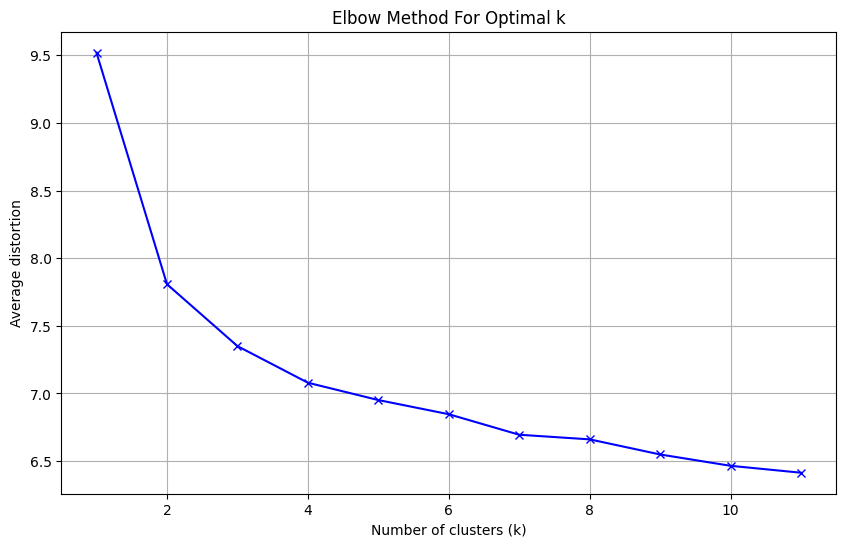

In [122]:
# Determine optimal number of clusters using the elbow method
distortions = []
K_range = range(1, MAX_NUM_CLUSTERS)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    distortions.append(sum(np.min(cdist(scaled_data, kmeans.cluster_centers_, 'euclidean'), axis=1)) / scaled_data.shape[0])

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, distortions, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average distortion')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

For n_clusters = 2, the silhouette score is 0.301
For n_clusters = 3, the silhouette score is 0.196
For n_clusters = 4, the silhouette score is 0.146
For n_clusters = 5, the silhouette score is 0.131
For n_clusters = 6, the silhouette score is 0.138
For n_clusters = 7, the silhouette score is 0.102
For n_clusters = 8, the silhouette score is 0.115
For n_clusters = 9, the silhouette score is 0.097


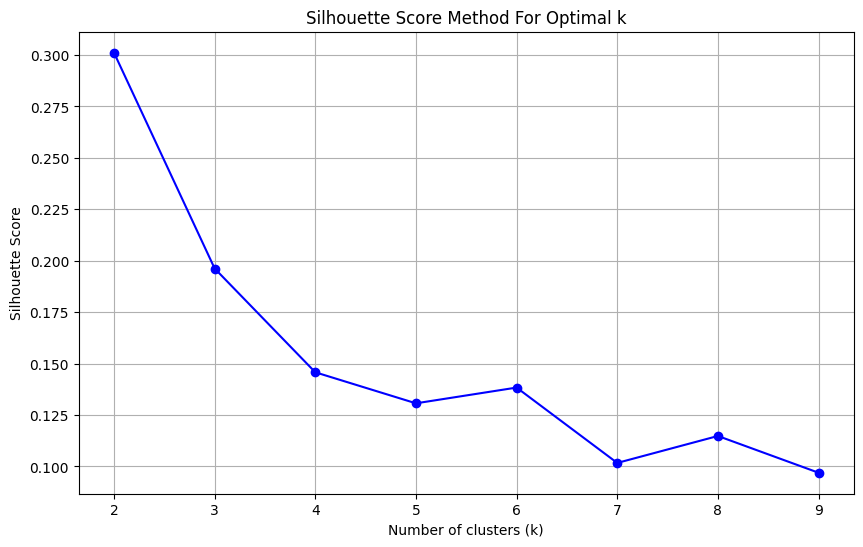

In [123]:
# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
for k in range(2, 10):  # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the silhouette score is {silhouette_avg:.3f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method For Optimal k')
plt.grid(True)
plt.show()

In [124]:
optimal_k = 4

In [125]:
# Apply K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

# Add cluster labels to the metadata
metadata['cluster'] = cluster_labels

# Calculate statistical descriptors for each width profile
stats = pd.DataFrame()
stats['y'] = metadata['y_coordinate']
stats['z'] = metadata['z_coordinate']
stats['power'] = metadata['power']
stats['cluster'] = metadata['cluster']

# Calculate statistics for each row in the original width data
stats['mean_width'] = width_data.mean(axis=1)
stats['median_width'] = width_data.median(axis=1)
stats['std_width'] = width_data.std(axis=1)
stats['p5_width'] = width_data.quantile(0.05, axis=1)
stats['p95_width'] = width_data.quantile(0.95, axis=1)
stats['range_width'] = width_data.max(axis=1) - width_data.min(axis=1)

# Print statistics by cluster
print("\nStatistical descriptors by cluster:")
cluster_stats = stats.groupby('cluster').mean()
print(cluster_stats)


Statistical descriptors by cluster:
                y         z  power  mean_width  median_width  std_width  \
cluster                                                                   
0        1.992523  0.696262  180.0   22.554339     22.271028   3.375007   
1        1.547256  0.666159  180.0   20.417015     20.036585   3.003043   
2        2.069128  0.426510  180.0   18.328028     18.073826   2.190605   
3        2.016379  0.671552  180.0   24.670115     23.551724   4.725873   

          p5_width  p95_width  range_width  
cluster                                     
0        18.474766  28.248598    21.336449  
1        17.073171  25.669512    19.969512  
2        15.777181  22.001342    14.355705  
3        19.362069  33.320690    26.155172  


In [126]:
# Count samples in each cluster
cluster_counts = stats['cluster'].value_counts().sort_index()
print("\nNumber of samples in each cluster:")
print(cluster_counts)


Number of samples in each cluster:
cluster
0    107
1    164
2    149
3     58
Name: count, dtype: int64


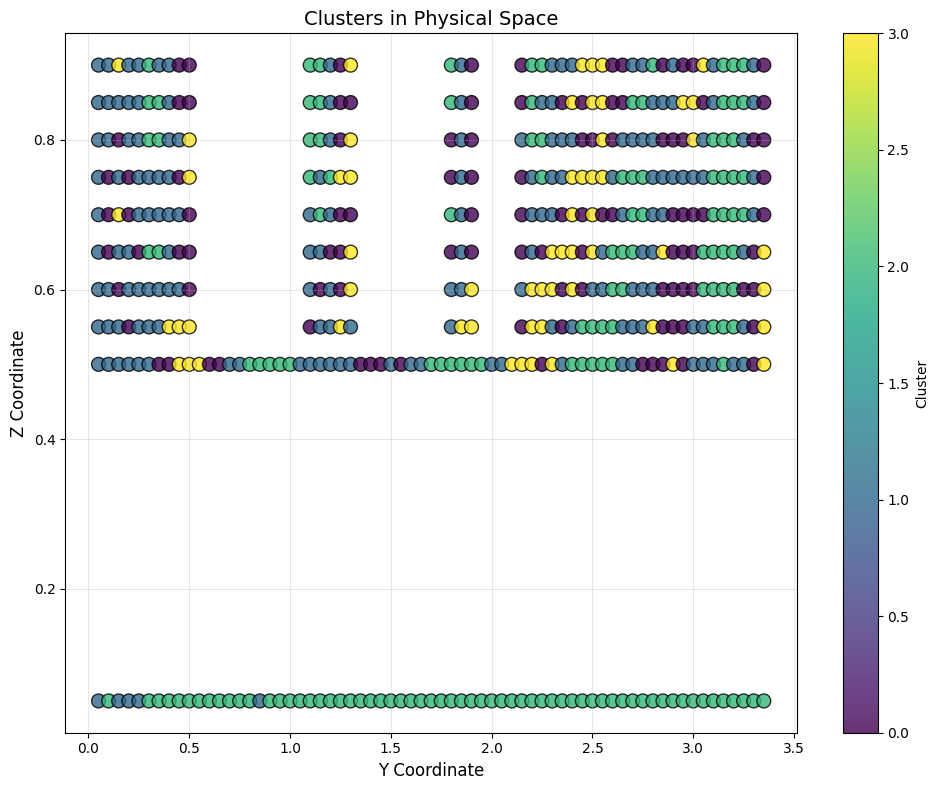

In [127]:
# Visualize the clusters in the physical space (y, z coordinates)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(stats['y'], stats['z'], c=stats['cluster'], cmap='viridis',
                     s=100, alpha=0.8, edgecolors='k')
plt.xlabel('Y Coordinate', fontsize=12)
plt.ylabel('Z Coordinate', fontsize=12)
plt.title('Clusters in Physical Space', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

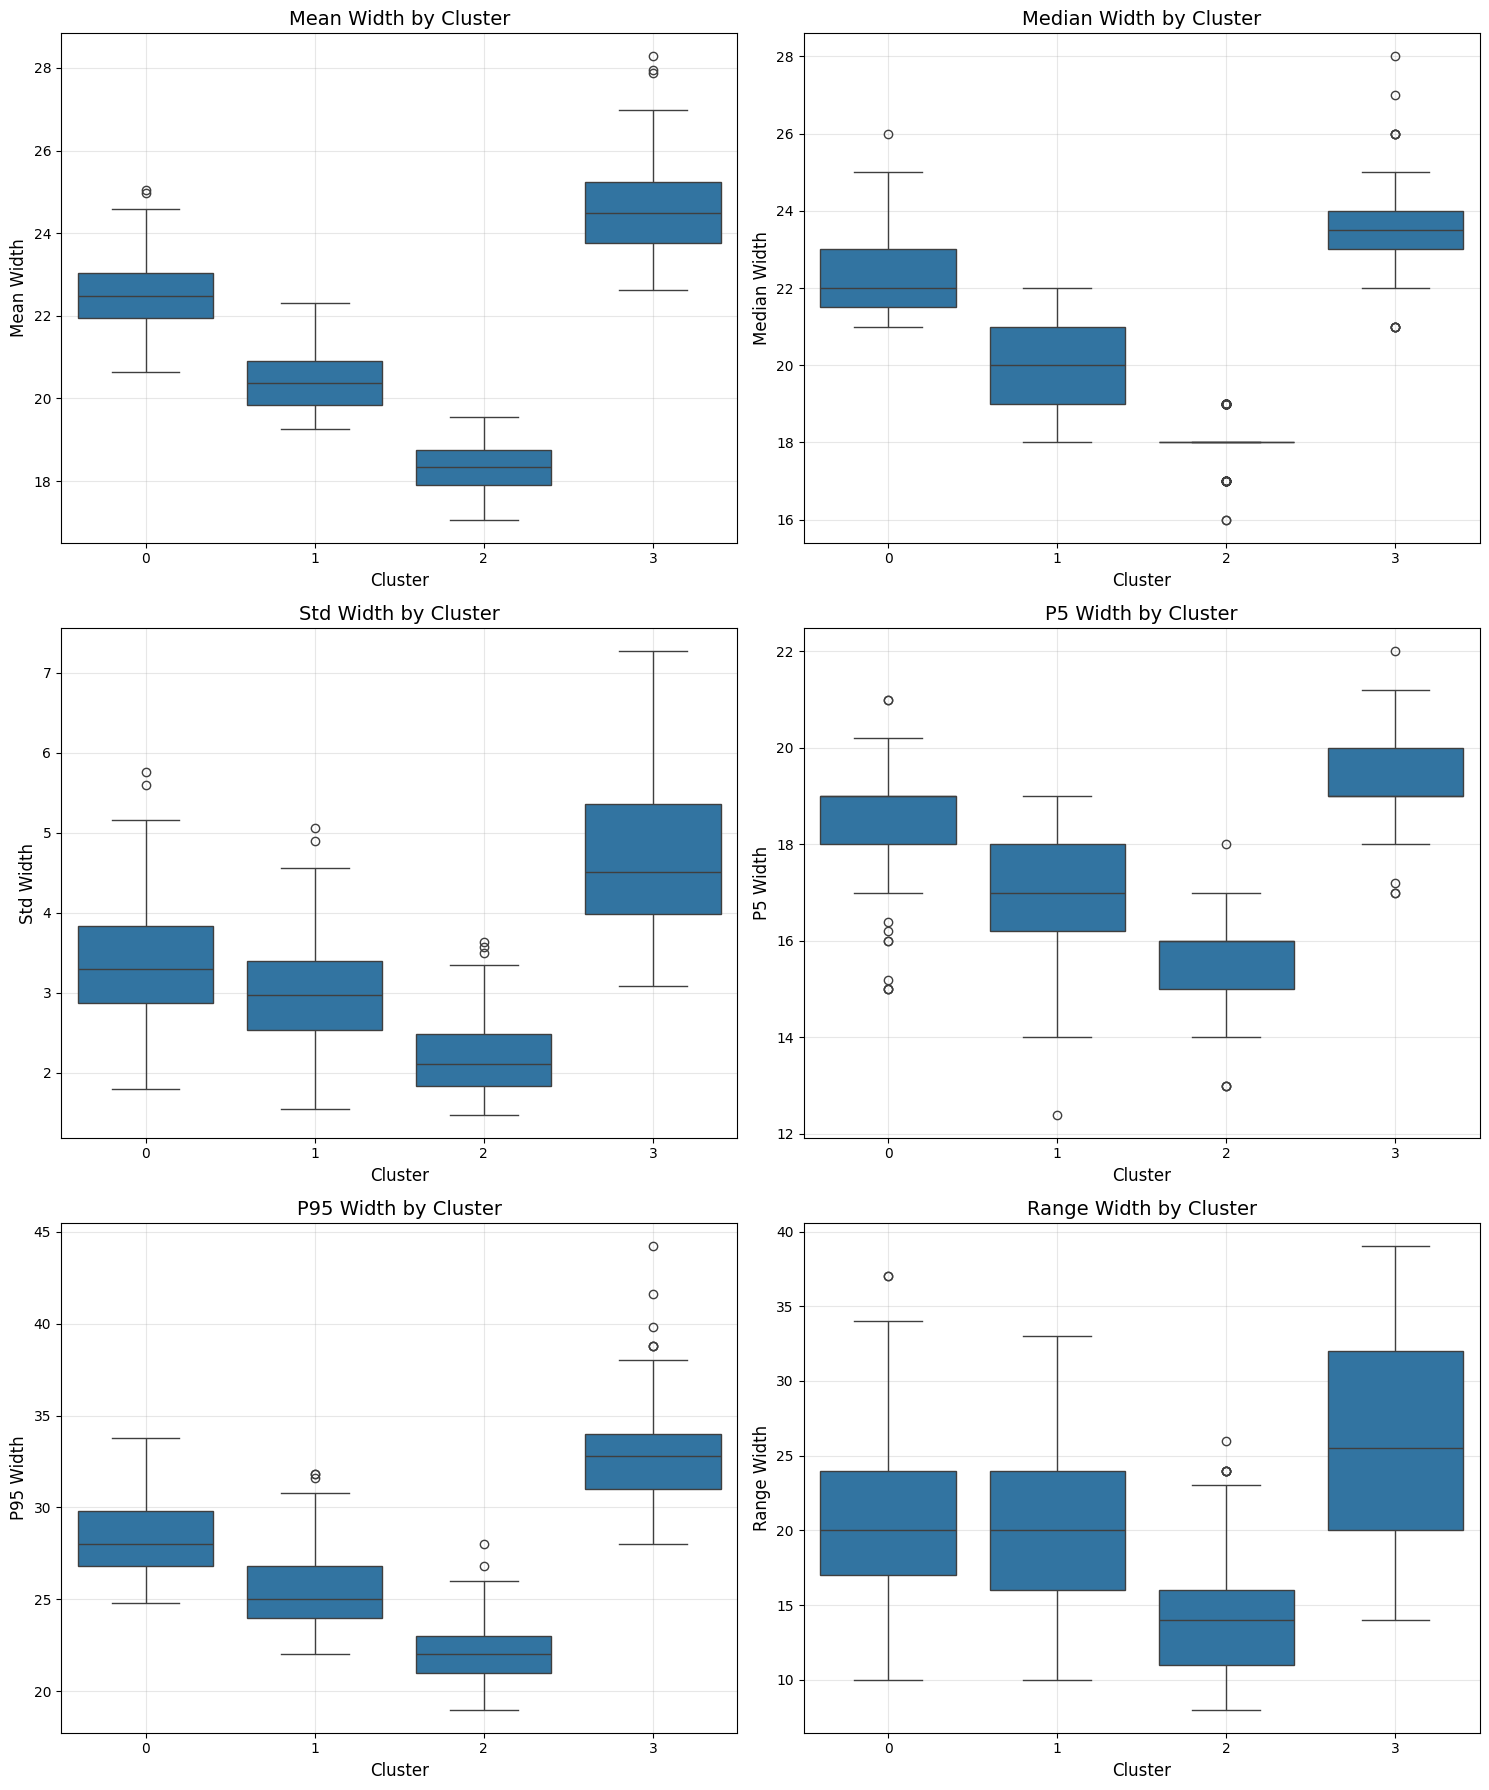

In [128]:
# Visualize statistical descriptors for each cluster
metrics = ['mean_width', 'median_width', 'std_width', 'p5_width', 'p95_width', 'range_width']
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(x='cluster', y=metric, data=stats, ax=ax)
    ax.set_title(f'{metric.replace("_", " ").title()} by Cluster', fontsize=14)
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

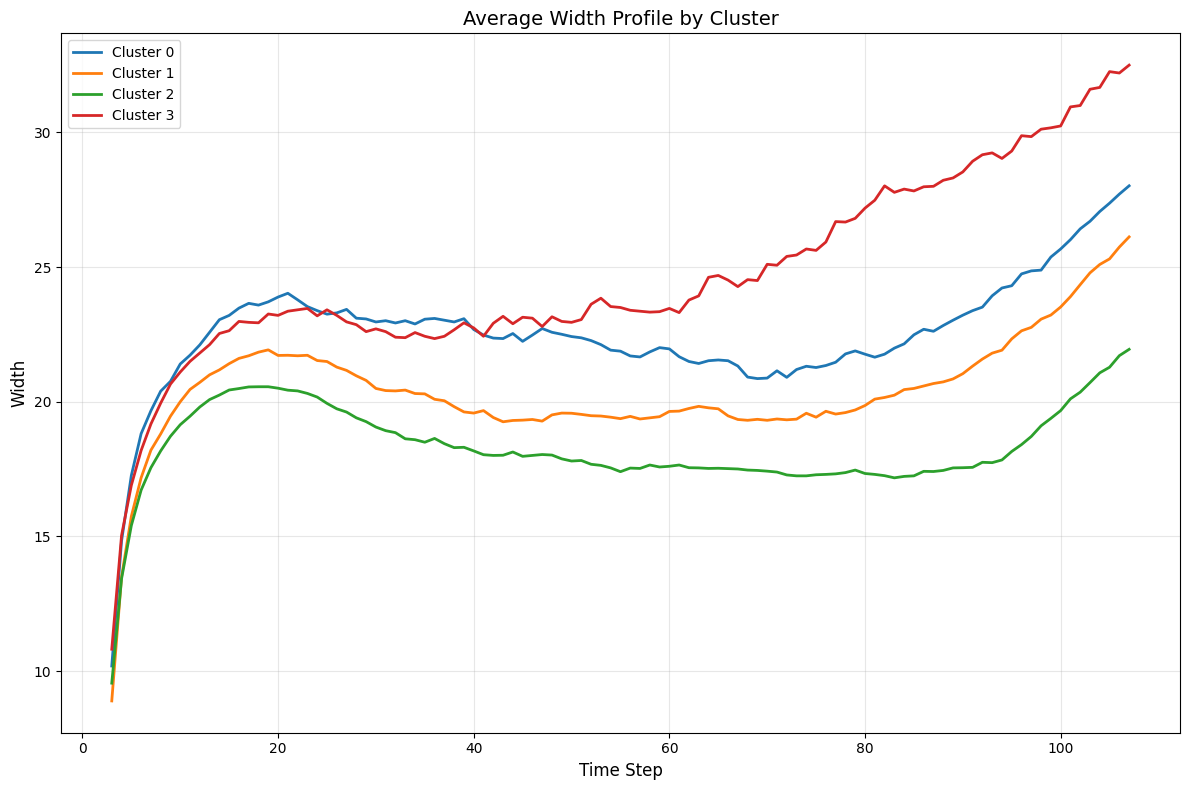

In [129]:
# Plot the average width profile for each cluster - with proper handling of NaN values
plt.figure(figsize=(12, 8))
for cluster_id in range(optimal_k):
    # Get indices of samples in this cluster
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    # Calculate the mean profile for this cluster, handling NaN values
    cluster_data = width_data.iloc[cluster_indices]
    cluster_mean_profile = cluster_data.mean(axis=0)
    # Plot the mean profile
    plt.plot(cluster_mean_profile, label=f'Cluster {cluster_id}', linewidth=2)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Width', fontsize=12)
plt.title('Average Width Profile by Cluster', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

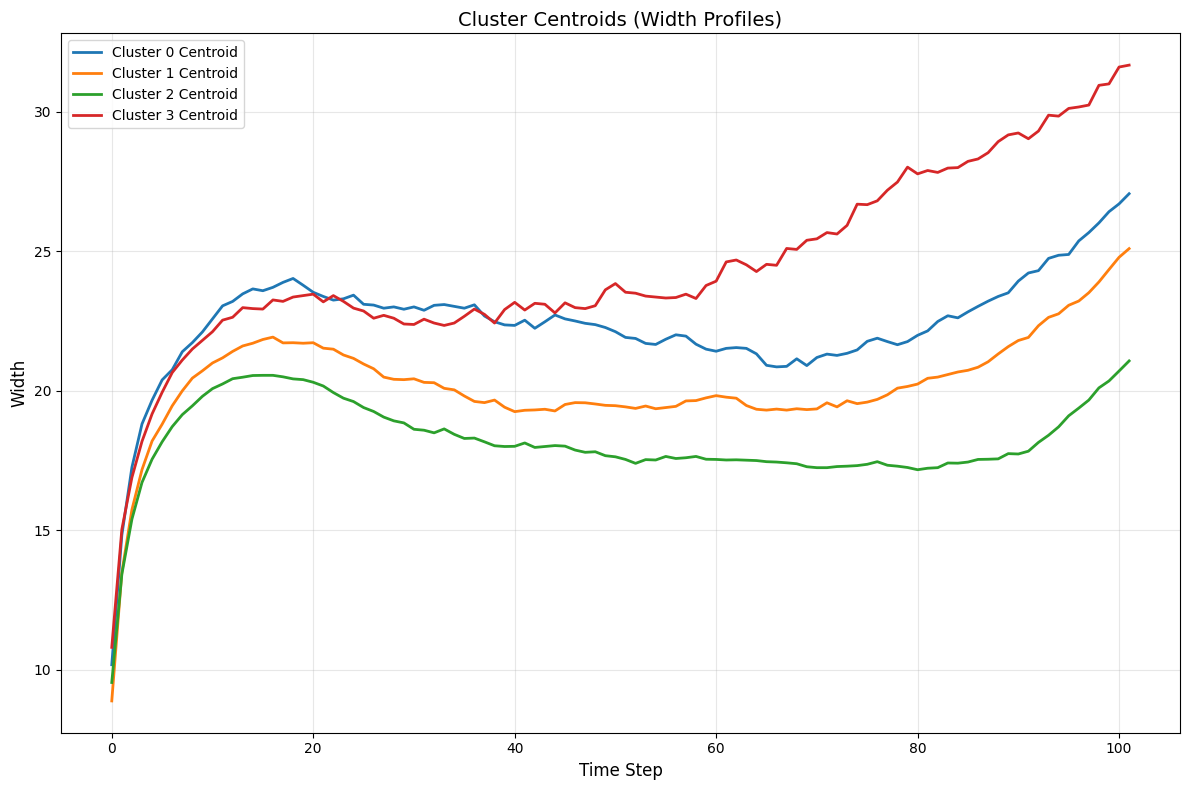

In [130]:
# Plot the actual centroids from K-means
plt.figure(figsize=(12, 8))
# Get centroids from K-means
centroids = kmeans.cluster_centers_
# Inverse transform to get back to the original scale
centroids_original = scaler.inverse_transform(centroids)

for cluster_id in range(optimal_k):
    # Plot the centroid profile for this cluster
    plt.plot(centroids_original[cluster_id][:-3], label=f'Cluster {cluster_id} Centroid', linewidth=2)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Width', fontsize=12)
plt.title('Cluster Centroids (Width Profiles)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
centroids_original[:,:-5].shape

(4, 100)

In [132]:
80/50400*700 * 10 ** 3

1111.111111111111

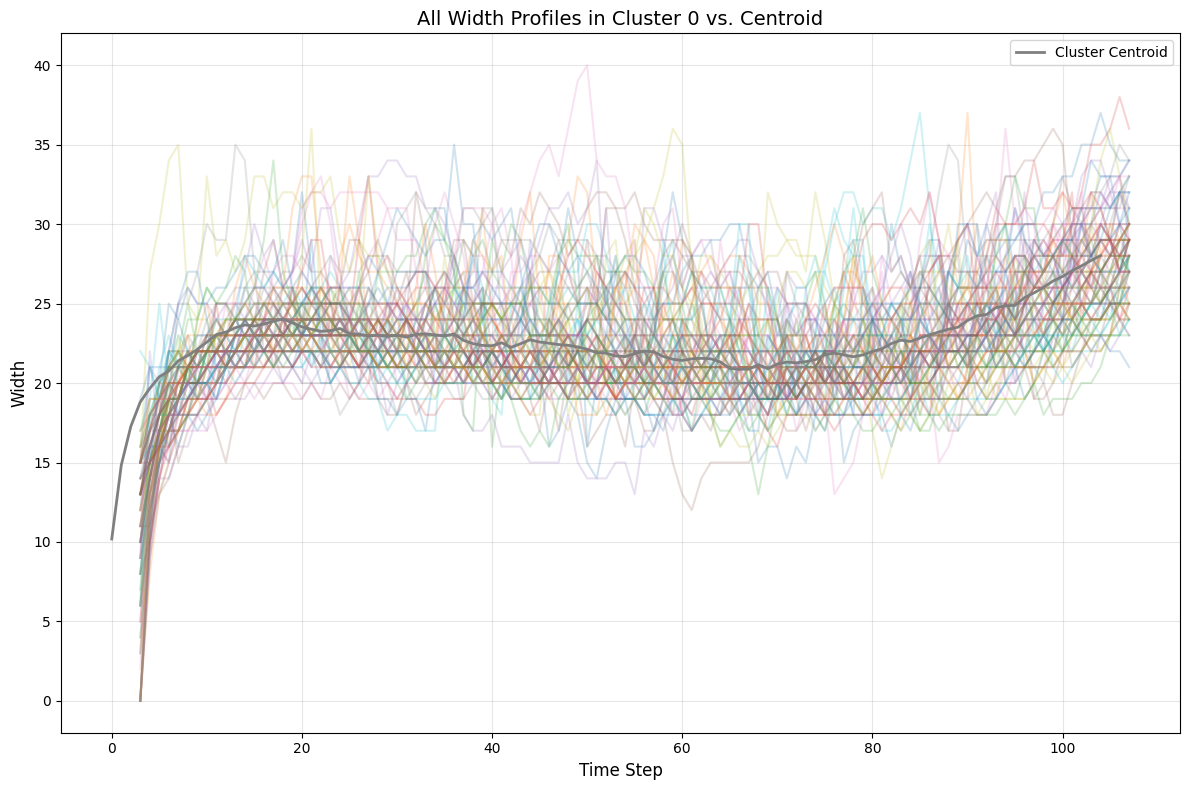

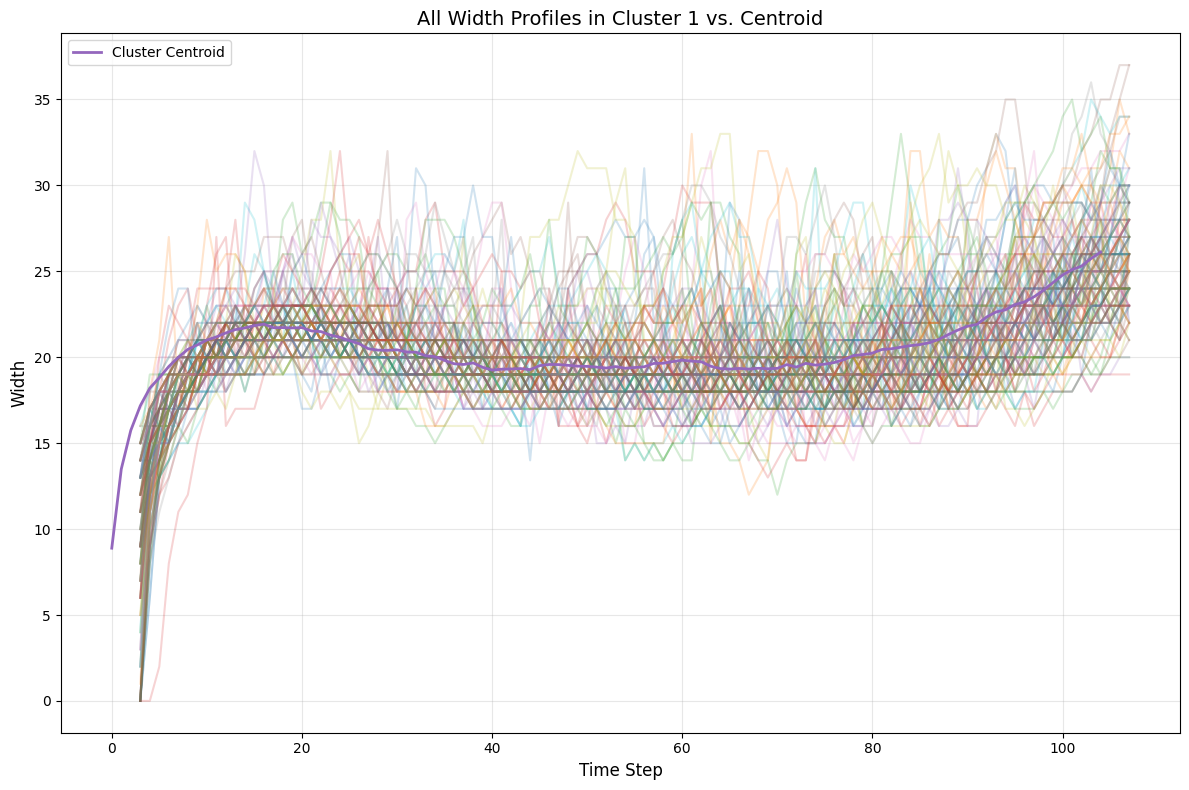

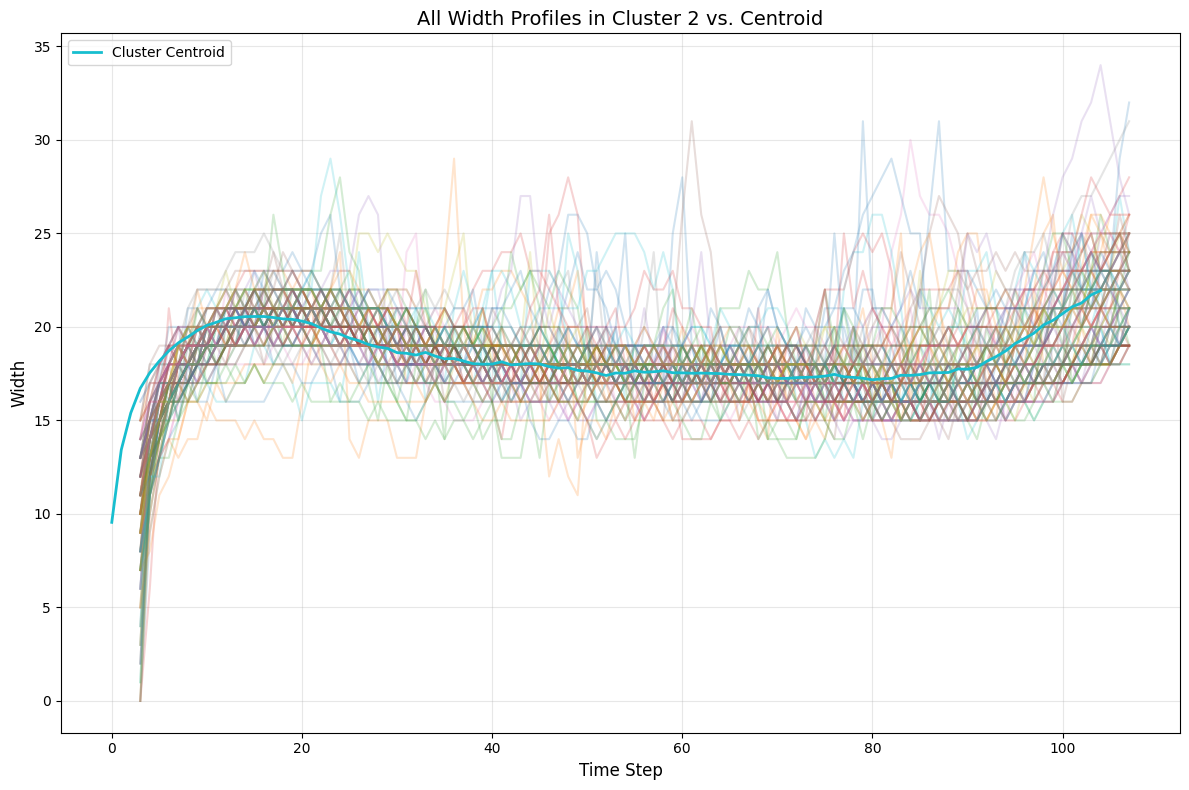

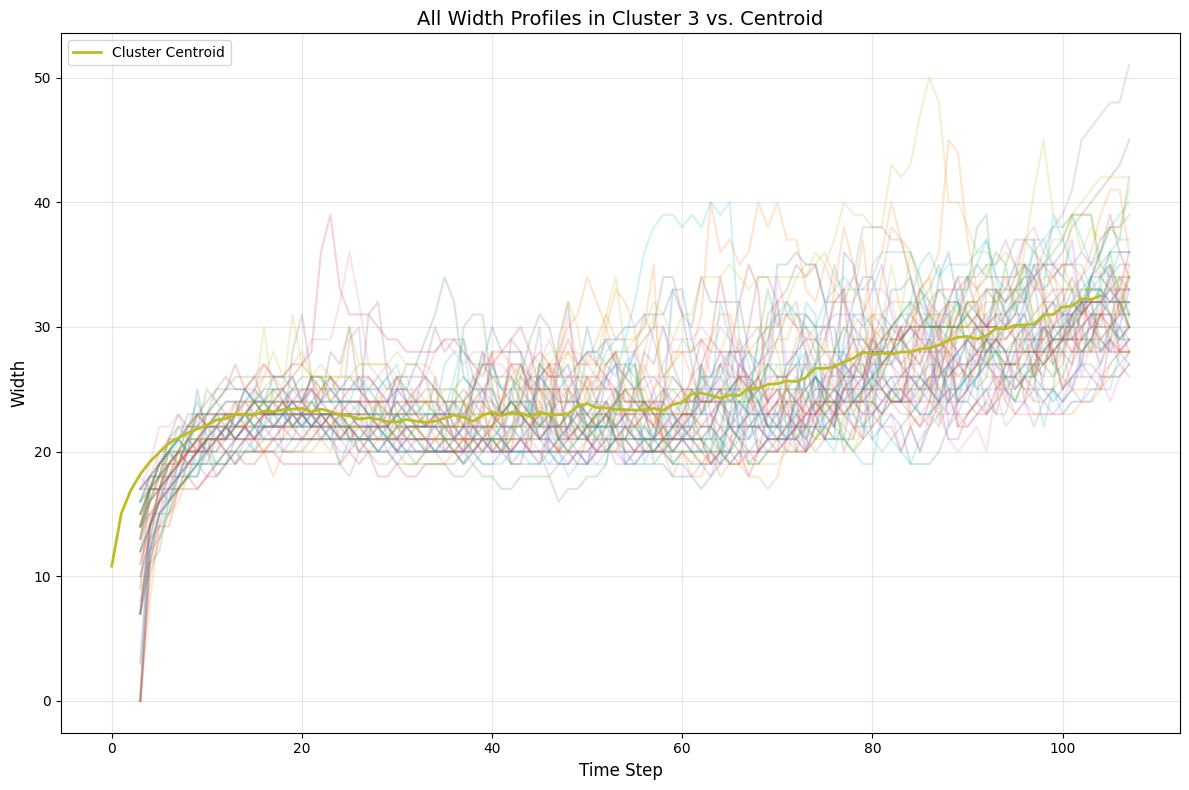

In [133]:
# Plot ALL the width profiles for each cluster, along with the centroid
for cluster_id in range(optimal_k):
    # Create a new figure for each cluster
    plt.figure(figsize=(12, 8))
    
    # Get the rows (indices) belonging to the current cluster
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_data = width_data.iloc[cluster_indices]
    
    # Plot every profile in the cluster (using alpha for a 'shaded' look)
    for i in range(cluster_data.shape[0]):
        plt.plot(cluster_data.iloc[i, :], alpha=0.2)
    
    # Plot the cluster centroid on top (already in original scale)
    plt.plot(centroids_original[cluster_id], linewidth=2, label='Cluster Centroid')
    
    # Add labels, legend, and a title
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Width', fontsize=12)
    plt.title(f'All Width Profiles in Cluster {cluster_id} vs. Centroid', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
